In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import numpy.linalg as LA
import scipy.constants as const
from scipy.spatial.transform import Rotation

import matplotlib.pyplot as plt
%matplotlib ipympl


import sys
sys.path.append('E:/google-drive/py_projects/satellites/src')
# import satellites as sat
import stateest as se
import utils

In [2]:
rng = np.random.default_rng(seed=4211)

In [3]:
se.gen_newtonian_motion_update_matrix(0.01, 2)

array([[0.e+00, 1.e-02, 5.e-05],
       [0.e+00, 0.e+00, 1.e-02],
       [0.e+00, 0.e+00, 0.e+00]])


# Example: tracking 1D position with constant velocity

## Simulate some noisy measurements

In [125]:
time_step = 0.5
n_measurements = 120
timevec = np.arange(n_measurements) * time_step
xtrue_init = 10
vtrue = 10
vmeas = vtrue + rng.normal(0, 2, n_measurements)
xtrue = np.cumsum(time_step*vmeas) + xtrue_init 
xmeas = xtrue + rng.normal(0, 1, n_measurements)

measurements = xmeas
# measurements = np.vstack((xmeas, vmeas)).T


## Kalman Filter 

True position: ['15.93', '20.88', '25.23', '30.96', '36.68', '43.76', '49.99', '56.00', '59.98', '64.32', '69.65', '75.93', '79.50', '84.42', '89.37', '95.45', '100.26', '105.82', '112.85', '118.28', '121.34', '126.31', '131.37', '137.24', '142.60', '148.40', '152.39', '158.12', '163.04', '168.96', '173.20', '178.70', '184.82', '190.25', '196.04', '203.05', '206.63', '212.01', '220.14', '225.22', '228.79', '233.04', '238.86', '244.99', '248.84', '253.15', '258.30', '263.41', '267.96', '273.73', '279.78', '285.10', '290.04', '293.24', '298.46', '303.03', '308.37', '311.48', '317.72', '322.67', '327.70', '333.77', '337.27', '342.37', '346.31', '351.61', '354.91', '359.86', '364.75', '369.69', '374.59', '377.60', '382.75', '387.42', '392.02', '396.00', '401.31', '405.94', '408.97', '413.03', '418.24', '422.52', '426.83', '430.82', '436.91', '441.87', '448.03', '454.53', '459.40', '463.61', '467.04', '472.00', '477.48', '482.17', '487.94', '492.47', '498.42', '501.94', '508.17', '512.14', 

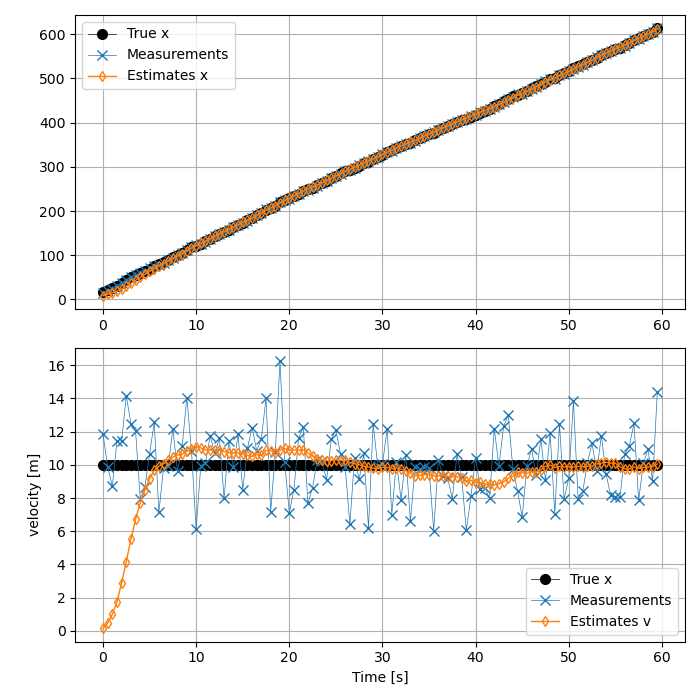

In [ ]:

dt = time_step
# state: [position, velocity]       
F = se.gen_newtonian_motion_update_matrix(dt, state_vec_order=1)
# measurement process (state to measurement)
H = np.array([[1,0]])
# H = np.array([
#     [1, 0],
#     [0, 1]
#     ])
# process noise
Q = np.array([
    [1, 0],
    [0, 1]
    ]) *1
# measurement noise
R = np.array([[201]])
# R = np.array([
#     [0.1, 0],
#     [0, 0.1]
#     ]) 

# initial state
x0 = np.array([[5, 0]]).T
# initial uncertainty. make high to convey broader prior
P0 = np.array([
    [100, 0],
    [0, 9],
])         
# controls
B = np.eye(2)
u = np.zeros_like(x0)

# init Kalman filter
kf = se.KalmanFilter(x0, P0, F, B, u, Q, H, R )

for z in measurements:
    x_est, _ = kf.perform_epoch(u=None, z=z.reshape([-1,1]), postcovkwargs={'stable':True})


print("True position:", [f"{e:.2f}" for e in xtrue])
print("Measured:", [f"{e:.2f}" for e in xmeas])
# estimatesxv = np.reshape(kf.x,[-1,2])[2::2, :]
estimatesxv = kf.get_states(which='estimates')
print("Estimates:", [f"{e:.2f}" for e in estimatesxv[:,0]])
kfstates = kf.get_states(which='all')

fig, axs = plt.subplots(2,1, figsize=[7,7])
axs[0].plot(timevec, xtrue, lw=0.5, marker='o', ms=7, color='k', label='True x')
axs[0].plot(timevec, xmeas, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
axs[0].plot(timevec, estimatesxv[:,0], lw=1, marker='d', ms=5, color='tab:orange', mfc='none',label='Estimates x')
# axs[0].plot( dt*(0.5*np.arange(kfstates.shape[0]) - 1) , kfstates[:,0], lw=1, marker='x', ms=5, color='tab:orange', label='all states')
axs[0].legend()

axs[1].plot(timevec, vtrue*np.ones(n_measurements), lw=0.5, marker='o', ms=7, color='k', label='True v')
axs[1].plot(timevec, vmeas, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
axs[1].plot(timevec, estimatesxv[:,1], lw=1, marker='d', ms=5, color='tab:orange',mfc='none', label='Estimates v')
# axs[1].plot( dt*(0.5*np.arange(kfstates.shape[0]) - 1) , kfstates[:,1], lw=1, marker='x', ms=5, color='tab:orange', label='all states')

axs[1].legend()

axkwargs = {
    # 'xticks': timevec[::10],
    # 'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'velocity [m]',
}
axs[1].set(**axkwargs)
for ax in axs:
    ax.grid(True)
    
plt.tight_layout()
plt.show()

In [106]:
plt.close('all')

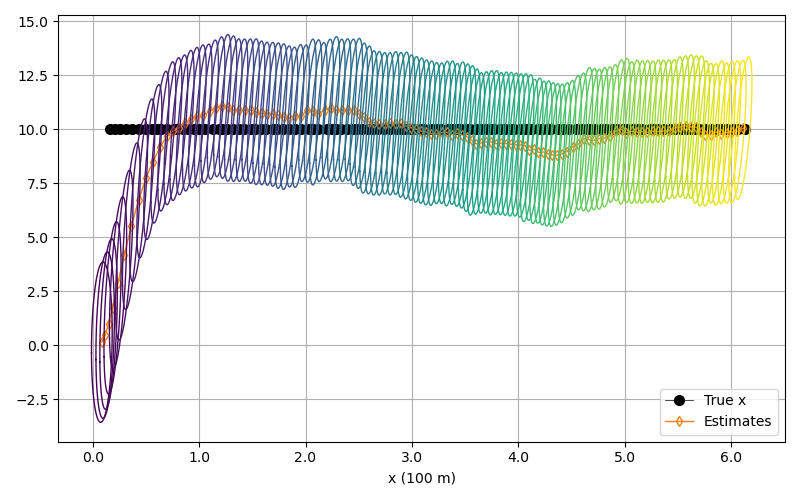

In [ ]:

colors = plt.cm.viridis(np.linspace(0, 1, n_measurements))

fig, ax = plt.subplots(1,1, figsize=[8,5], squeeze=True)
ax.plot(xtrue, vtrue*np.ones_like(xtrue), lw=0.5, marker='o', ms=7, color='k', label='True x-v')
# ax.plot( measurements[:,0], measurements[:,1], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
ax.plot( estimatesxv[:,0], estimatesxv[:,1], lw=1, marker='d', ms=5, color='tab:orange', mfc='none', label='Estimates')

estimates_cov = kf.get_covariances(which='estimates')
for i, (xv, cov) in enumerate(zip(estimatesxv, estimates_cov)):
    xy = utils.generate_covariance_ellipse(xv, cov, enclosed_frac=0.5)
    ax.plot(xy[0], xy[1], lw=1, color=colors[i])
    # ax.plot(xv[0], xv[1], c=colors[i])
ax.legend()
# ax.plot(timevec, measurements[:,0] - true_positions, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurement - Truth')
# ax.plot(timevec, estimates - true_positions, lw=1, marker='x', ms=5, color='tab:red', label='Estimate - Truth')
# ax.legend()

axkwargs = {
    # 'xticks': timevec[::10],
    # 'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'Position difference from truth [m]',
    'aspect': 'equal',
}
# axs[1].set(**axkwargs)
from matplotlib.ticker import FuncFormatter

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: x / 100))
ax.set_xlabel('x (100 m)')

ax.grid(True)
plt.tight_layout()
plt.show()

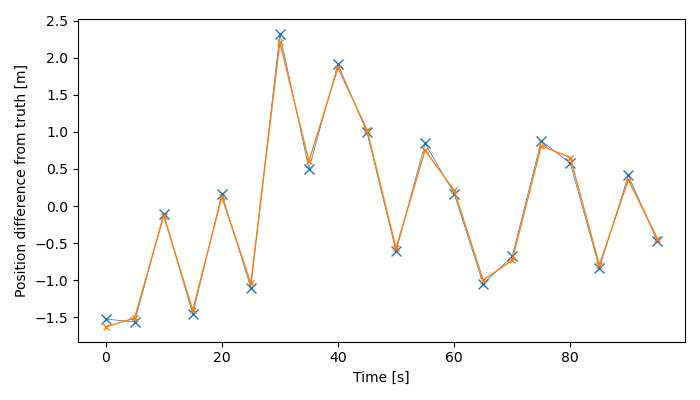

In [78]:
fig, ax = plt.subplots(1,1, figsize=[7,4])

ax.plot(timevec, xmeas - xtrue, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurement - Truth')
ax.plot(timevec, estimatesxv[:,0] - xtrue, lw=1, marker='x', ms=5, color='tab:orange', label='Estimatex - Truth')

axkwargs = {
    # 'xticks': timevec,
    # 'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'Position difference from truth [m]',
}
ax.set(**axkwargs)
plt.tight_layout()
plt.show()


# Example: tracking 2D position with constant velocity

## Simulate some noisy measurements

In [157]:
time_step = 0.5
n_measurements = 120
timevec = np.arange(n_measurements) * time_step
xtrue_init = np.array([10,-5.23])
vtrue = np.array([4.211, -1.823])
vmeas = vtrue + rng.normal(0, 2, [n_measurements,2])
xtrue = np.cumsum(time_step*vmeas, axis=0) + xtrue_init 
xmeas = xtrue + rng.normal(0, 1, [n_measurements,2])

measurements = xmeas
# measurements = np.vstack((xmeas, vmeas)).T
print(measurements.shape)

(120, 2)


## Kalman Filter 

[[1.  0.5 0.  0. ]
 [0.  1.  0.  0. ]
 [0.  0.  1.  0.5]
 [0.  0.  0.  1. ]]
True position: ['(12.46, -6.45)', '(12.23, -8.15)', '(13.49, -6.74)', '(16.97, -7.36)', '(20.41, -8.65)', '(23.04, -11.63)', '(24.58, -13.33)', '(24.32, -13.07)', '(27.35, -13.98)', '(28.29, -14.64)', '(30.09, -15.63)', '(32.68, -16.96)', '(34.84, -19.56)', '(37.79, -20.11)', '(40.24, -20.25)', '(42.20, -21.49)', '(43.18, -24.27)', '(45.89, -25.83)', '(48.63, -26.98)', '(51.07, -28.44)', '(50.94, -30.66)', '(54.88, -31.74)', '(59.45, -31.06)', '(61.07, -33.03)', '(63.17, -34.26)', '(67.56, -35.04)', '(71.16, -37.80)', '(73.14, -38.02)', '(75.11, -38.00)', '(76.41, -39.20)', '(78.16, -40.03)', '(80.00, -41.95)', '(82.40, -40.73)', '(83.40, -41.36)', '(85.23, -41.89)', '(86.85, -43.89)', '(87.72, -45.84)', '(90.13, -45.57)', '(90.99, -48.94)', '(91.12, -48.12)', '(93.54, -49.41)', '(95.16, -50.25)', '(99.11, -51.30)', '(101.95, -50.19)', '(103.47, -50.80)', '(105.11, -50.03)', '(106.80, -50.10)', '(109.02, -50.6

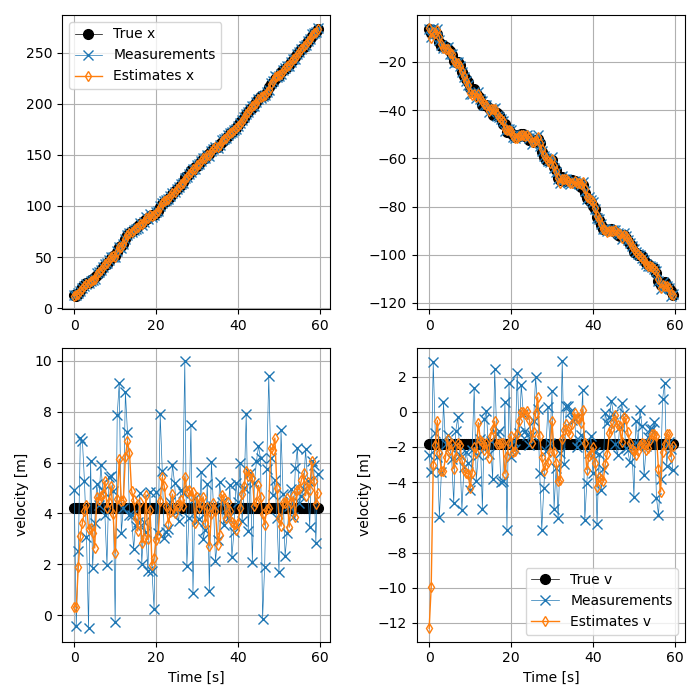

In [158]:

dt = time_step
# state: [position, velocity]       
F1 = se.gen_newtonian_motion_update_matrix(dt, state_vec_order=1)
state1_order = F1.shape[0]
F2 = se.gen_newtonian_motion_update_matrix(dt, state_vec_order=1)
state2_order = F2.shape[0]
F = np.block([
    [F1, np.zeros(shape=[state1_order, state2_order])],
    [np.zeros(shape=[state2_order, state1_order]), F2 ],
])
print(F)

# measurement process (state to measurement)
H = np.array([
    [1,0,0,0],
    [0,0,1,0],
    ])
# H = np.array([
#     [1, 0],
#     [0, 1]
#     ])
# process noise
Q = 1 * np.eye(state1_order+state2_order)
# measurement noise
R = np.array([
    [1, 0],
    [0, 1],
    ])

# initial state
x0 = np.array([[5, 0, 7, -12]]).T
# initial uncertainty. make high to convey broader prior
P0 = np.diag([100, 9, 100, 9])      
# controls
B = np.eye(4)
u = np.zeros_like(x0)

# init Kalman filter
kf = se.KalmanFilter(x0, P0, F, B, u, Q, H, R )

for z in measurements:
    x_est, _ = kf.perform_epoch(u=None, z=z.reshape([-1,1]), postcovkwargs={'stable':True})


print("True position:", [f"({e[0]:.2f}, {e[1]:.2f})" for e in xtrue])
print("Measured:", [f"({e[0]:.2f}, {e[1]:.2f})" for e in xmeas])

# estimatesxv = np.reshape(kf.x,[-1,2])[2::2, :]
estimatesxv = kf.get_states(which='estimates')
print("Estimates:", [f"{e:.2f}" for e in estimatesxv[:,0]])
kfstates = kf.get_states(which='all')

fig, axs = plt.subplots(2,2, figsize=[7,7])
for i in range(2):
    axs[0,i].plot(timevec, xtrue[:,i], lw=0.5, marker='o', ms=7, color='k', label='True x')
    axs[0,i].plot(timevec, xmeas[:,i], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
    axs[0,i].plot(timevec, estimatesxv[:,2*i], lw=1, marker='d', ms=5, color='tab:orange', mfc='none',label='Estimates x')
    
    axs[1,i].plot(timevec, vtrue[i]*np.ones(n_measurements), lw=0.5, marker='o', ms=7, color='k', label='True v')
    axs[1,i].plot(timevec, vmeas[:,i], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
    axs[1,i].plot(timevec, estimatesxv[:,2*i+1], lw=1, marker='d', ms=5, color='tab:orange',mfc='none', label='Estimates v')

# axs[0,0].plot( dt*(0.5*np.arange(kfstates.shape[0]) - 1) , kfstates[:,0], lw=1, marker='x', ms=5, color='tab:orange', label='all states')
axs[0,0].legend()

# axs[1,1].plot( dt*(0.5*np.arange(kfstates.shape[0]) - 1) , kfstates[:,1], lw=1, marker='x', ms=5, color='tab:orange', label='all states')

axs[1,1].legend()

axkwargs = {
    # 'xticks': timevec[::10],
    # 'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'velocity [m]',
}
for ax in axs[1]:
    ax.set(**axkwargs)
for ax in axs:
    for ax in ax:
        ax.grid(True)
    
plt.tight_layout()
plt.show()

In [134]:
estimatesxv.shape

(120, 4)

In [159]:
def get_position_covariances(cov, state_order=1):
    ndims = cov.shape[0]
    cc, rr = np.meshgrid(np.arange(ndims), np.arange(ndims))
    stride = state_order + 1
    rr = (rr % stride) == 0
    nr = np.sum(rr, axis=0)[0]
    # print(rr)
    cc = (cc % stride) == 0
    nc = np.sum(cc, axis=1)[0]
    # print(cc)
    mask = rr & cc
    # print(mask)

    return cov[mask].reshape([nr, nc])
ndims = 4
rr,cc = np.meshgrid(np.arange(ndims), np.arange(ndims))
print(rr)
print(cc)
print(P0+rr)
get_position_covariances(P0+rr, state_order=1)

[[0 1 2 3]
 [0 1 2 3]
 [0 1 2 3]
 [0 1 2 3]]
[[0 0 0 0]
 [1 1 1 1]
 [2 2 2 2]
 [3 3 3 3]]
[[100   1   2   3]
 [  0  10   2   3]
 [  0   1 102   3]
 [  0   1   2  12]]


array([[100,   2],
       [  0, 102]])

In [ ]:
plt.close('all')

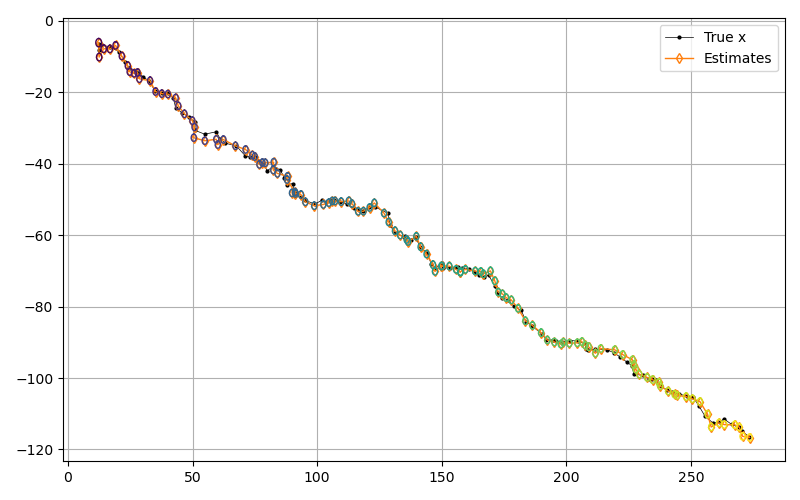

In [161]:

colors = plt.cm.viridis(np.linspace(0, 1, n_measurements))

fig, ax = plt.subplots(1,1, figsize=[8,5], squeeze=True)
ax.plot(xtrue[:,0], xtrue[:,1], lw=0.5, marker='o', ms=2, color='k', label='True x')
# ax.plot( measurements[:,0], measurements[:,1], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
ax.plot( estimatesxv[:,0], estimatesxv[:,2], lw=1, marker='d', ms=5, color='tab:orange', mfc='none', label='Estimates')

estimates_pos = [est[[0,2]] for est in estimatesxv]
estimates_cov = kf.get_covariances(which='estimates')
estimates_pos_cov = [get_position_covariances(cov,state_order=1) for cov in estimates_cov]
for i, (xv, cov) in enumerate(zip(estimates_pos, estimates_pos_cov)):
    xy = utils.generate_covariance_ellipse(xv, cov, enclosed_frac=0.5)
    ax.plot(xy[0], xy[1], lw=1, color=colors[i])
    # ax.plot(xv[0], xv[1], c=colors[i])
ax.legend()
# ax.plot(timevec, measurements[:,0] - true_positions, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurement - Truth')
# ax.plot(timevec, estimates - true_positions, lw=1, marker='x', ms=5, color='tab:red', label='Estimate - Truth')
# ax.legend()

axkwargs = {
    # 'xticks': timevec[::10],
    # 'ylim': [-20, 20],
    # 'xlabel': 'Time [s]',
    # 'ylabel': 'Position difference from truth [m]',
    'aspect': 'equal',
}
# axs[1].set(**axkwargs)
from matplotlib.ticker import FuncFormatter

# ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: x / 100))
# ax.set_xlabel('x (100 m)')

ax.grid(True)
plt.tight_layout()
plt.show()

# Example: tracking 2D position with constant velocity in polar coordinates

## Simulate some noisy measurements

In [250]:
time_step = 1
n_measurements = 45
timevec = np.arange(n_measurements) * time_step

xtrue_init = np.array([10, 0])
vtrue = np.array([0, 0.2318])
vmeas = vtrue + rng.normal(0, 1e-2, [n_measurements,2])
xtrue = np.cumsum(time_step*vmeas, axis=0) + xtrue_init 
xmeas = xtrue + rng.normal(0, 1e-1, [n_measurements,2])

measurements = xmeas
# measurements = np.vstack((xmeas, vmeas)).T
print(measurements.shape)

(45, 2)


## Kalman Filter 

[[1. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 1.]
 [0. 0. 0. 1.]]
True position: ['(10.00, 0.22)', '(10.02, 0.45)', '(10.01, 0.70)', '(10.00, 0.94)', '(10.00, 1.19)', '(9.99, 1.41)', '(10.00, 1.64)', '(9.99, 1.88)', '(10.00, 2.13)', '(10.00, 2.37)', '(10.01, 2.61)', '(10.00, 2.86)', '(9.98, 3.10)', '(9.99, 3.33)', '(9.98, 3.56)', '(9.96, 3.78)', '(9.96, 4.00)', '(9.96, 4.24)', '(9.97, 4.48)', '(9.98, 4.71)', '(9.97, 4.93)', '(9.97, 5.17)', '(9.97, 5.39)', '(9.97, 5.62)', '(9.97, 5.86)', '(9.97, 6.09)', '(9.97, 6.32)', '(9.96, 6.56)', '(9.96, 6.78)', '(9.98, 7.00)', '(9.99, 7.24)', '(9.99, 7.48)', '(9.99, 7.69)', '(10.00, 7.93)', '(10.02, 8.15)', '(10.04, 8.39)', '(10.03, 8.63)', '(10.05, 8.86)', '(10.04, 9.08)', '(10.04, 9.32)', '(10.03, 9.54)', '(10.03, 9.77)', '(10.03, 9.99)', '(10.01, 10.22)', '(10.01, 10.47)']
Measured: ['(10.05, 0.22)', '(9.85, 0.32)', '(10.18, 0.68)', '(10.10, 1.12)', '(9.90, 1.17)', '(9.88, 1.59)', '(10.06, 1.62)', '(10.06, 1.86)', '(10.04, 2.06)', '(9.90, 2.29)', '(

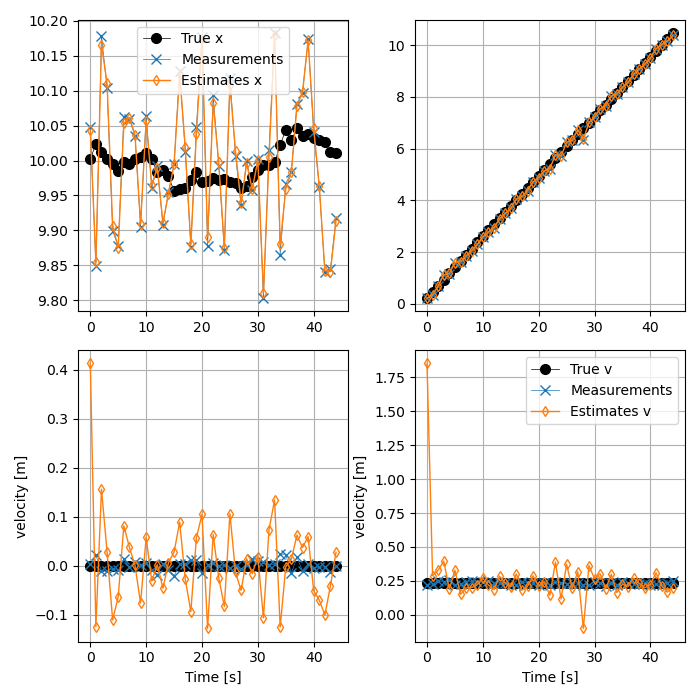

In [251]:

dt = time_step
# state: [position, velocity]       
F1 = se.gen_newtonian_motion_update_matrix(dt, state_vec_order=1)
state1_order = F1.shape[0]
F2 = se.gen_newtonian_motion_update_matrix(dt, state_vec_order=1)
state2_order = F2.shape[0]
F = np.block([
    [F1, np.zeros(shape=[state1_order, state2_order])],
    [np.zeros(shape=[state2_order, state1_order]), F2 ],
])
print(F)

# measurement process (state to measurement)
H = np.array([
    [1,0,0,0],
    [0,0,1,0],
    ])
# H = np.array([
#     [1, 0],
#     [0, 1]
#     ])
# process noise
Q = 1 * np.eye(state1_order+state2_order)
# measurement noise
R = np.array([
    [0.1, 0],
    [0, np.pi/90],
    ])

# initial state
x0 = np.array([[5, 0, 0, 2]]).T
# initial uncertainty. make high to convey broader prior
P0 = np.diag([100, 9, 100, 9])      
# controls
B = np.eye(4)
u = np.zeros_like(x0)

# init Kalman filter
kf = se.KalmanFilter(x0, P0, F, B, u, Q, H, R )

for z in measurements:
    x_est, _ = kf.perform_epoch(u=None, z=z.reshape([-1,1]), postcovkwargs={'stable':True})


print("True position:", [f"({e[0]:.2f}, {e[1]:.2f})" for e in xtrue])
print("Measured:", [f"({e[0]:.2f}, {e[1]:.2f})" for e in xmeas])

# estimatesxv = np.reshape(kf.x,[-1,2])[2::2, :]
estimatesxv = kf.get_states(which='estimates')
print("Estimates:", [f"{e:.2f}" for e in estimatesxv[:,0]])
kfstates = kf.get_states(which='all')

fig, axs = plt.subplots(2,2, figsize=[7,7])
for i in range(2):
    axs[0,i].plot(timevec, xtrue[:,i], lw=0.5, marker='o', ms=7, color='k', label='True x')
    axs[0,i].plot(timevec, xmeas[:,i], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
    axs[0,i].plot(timevec, estimatesxv[:,2*i], lw=1, marker='d', ms=5, color='tab:orange', mfc='none',label='Estimates x')
    
    axs[1,i].plot(timevec, vtrue[i]*np.ones(n_measurements), lw=0.5, marker='o', ms=7, color='k', label='True v')
    axs[1,i].plot(timevec, vmeas[:,i], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
    axs[1,i].plot(timevec, estimatesxv[:,2*i+1], lw=1, marker='d', ms=5, color='tab:orange',mfc='none', label='Estimates v')

# axs[0,0].plot( dt*(0.5*np.arange(kfstates.shape[0]) - 1) , kfstates[:,0], lw=1, marker='x', ms=5, color='tab:orange', label='all states')
axs[0,0].legend()

# axs[1,1].plot( dt*(0.5*np.arange(kfstates.shape[0]) - 1) , kfstates[:,1], lw=1, marker='x', ms=5, color='tab:orange', label='all states')

axs[1,1].legend()

axkwargs = {
    # 'xticks': timevec[::10],
    # 'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'velocity [m]',
}
for ax in axs[1]:
    ax.set(**axkwargs)
for ax in axs:
    for ax in ax:
        ax.grid(True)
    
plt.tight_layout()
plt.show()

In [ ]:
estimatesxv.shape

(120, 4)

In [ ]:
plt.close('all')

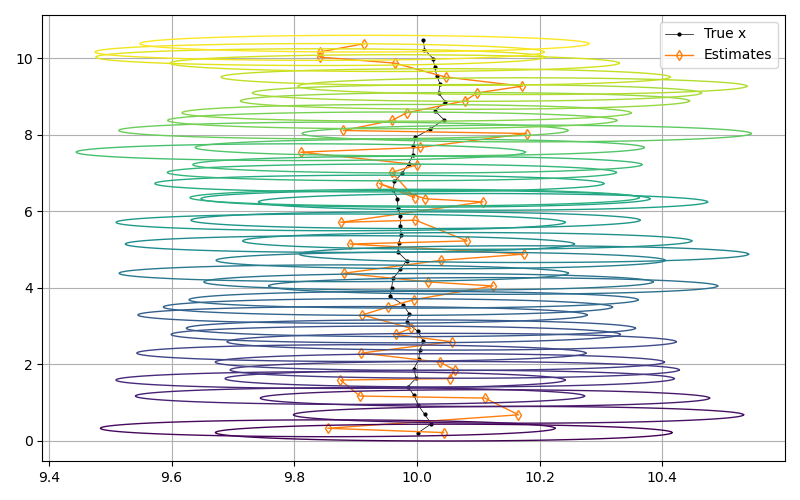

In [252]:

colors = plt.cm.viridis(np.linspace(0, 1, n_measurements))

fig, ax = plt.subplots(1,1, figsize=[8,5], squeeze=True)
ax.plot(xtrue[:,0], xtrue[:,1], lw=0.5, marker='o', ms=2, color='k', label='True x')
# ax.plot( measurements[:,0], measurements[:,1], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
ax.plot( estimatesxv[:,0], estimatesxv[:,2], lw=1, marker='d', ms=5, color='tab:orange', mfc='none', label='Estimates')

estimates_pos = [est[[0,2]] for est in estimatesxv]
estimates_cov = kf.get_covariances(which='estimates')
estimates_pos_cov = [get_position_covariances(cov,state_order=1) for cov in estimates_cov]
for i, (xv, cov) in enumerate(zip(estimates_pos, estimates_pos_cov)):
    xy = utils.generate_covariance_ellipse(xv, cov, enclosed_frac=0.5)
    ax.plot(xy[0], xy[1], lw=1, color=colors[i])
    # ax.plot(xv[0], xv[1], c=colors[i])
ax.legend()
# ax.plot(timevec, measurements[:,0] - true_positions, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurement - Truth')
# ax.plot(timevec, estimates - true_positions, lw=1, marker='x', ms=5, color='tab:red', label='Estimate - Truth')
# ax.legend()

axkwargs = {
    # 'xticks': timevec[::10],
    # 'ylim': [-20, 20],
    # 'xlabel': 'Time [s]',
    # 'ylabel': 'Position difference from truth [m]',
    'aspect': 'equal',
}
# axs[1].set(**axkwargs)
from matplotlib.ticker import FuncFormatter

# ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: x / 100))
# ax.set_xlabel('x (100 m)')

ax.grid(True)
plt.tight_layout()
plt.show()

### Transform Gaussian distribution from polar to Cartesian

In [253]:
from scipy.stats import multivariate_normal
n = 42
state_mu = kf.x[n]
state_sig = kf.P[n]
rth_mu = state_mu[[0,2]].squeeze()
rth_sig = utils.get_position_covariances(state_sig, state_order=1)
print(rth_mu)
print(rth_sig)
rth_dist = multivariate_normal(rth_mu, rth_sig)
rth_samples = rth_dist.rvs(10000)
print(rth_samples.shape)
x_samples, y_samples = utils.polar_to_cartesian(rth_samples[:,0], rth_samples[:,1])
xy_samples = np.vstack((x_samples, y_samples)).T
print(xy_samples.shape)
xy_mu = np.mean(xy_samples, axis=0)
print(xy_mu)
xy_sig = np.cov(xy_samples.T)
print(xy_sig)

[10.17437158  4.87860653]
[[0.09664561 0.        ]
 [0.         0.03446321]]
(10000, 2)
(10000, 2)
[ 1.65013305 -9.86034611]
[[3.36049279 0.53984297]
 [0.53984297 0.24151519]]


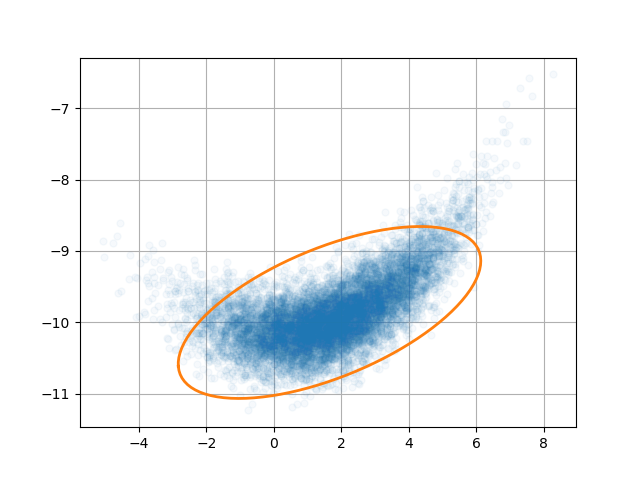

In [254]:
fig, ax = plt.subplots(1,1)
ax.plot(x_samples, y_samples, lw=0, marker='o', ms=5, alpha=0.04)
elpts = utils.generate_covariance_ellipse(xy_mu, xy_sig, enclosed_frac=0.95)
ax.plot(elpts[0], elpts[1], lw=2, color='tab:orange')

ax.grid(True)
plt.show()

In [255]:


postrue_x, postrue_y = utils.polar_to_cartesian(xtrue[:,0], xtrue[:,1])
posmeas_x, posmeas_y = utils.polar_to_cartesian(measurements[:,0], measurements[:,1])
posest_x, posest_y = utils.polar_to_cartesian(estimatesxv[:,0], estimatesxv[:,2])


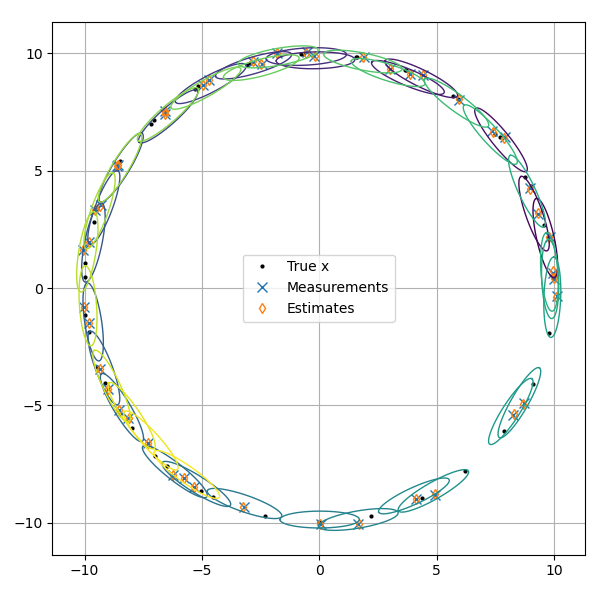

In [256]:

colors = plt.cm.viridis(np.linspace(0, 1, n_measurements))

fig, ax = plt.subplots(1,1, figsize=[6,6], squeeze=True)
ax.plot(postrue_x, postrue_y, lw=0, marker='o', ms=2, color='k', label='True x')
ax.plot(posmeas_x, posmeas_y, lw=0, marker='x', ms=7, color='tab:blue', label='Measurements')
ax.plot(posest_x, posest_y, lw=0, marker='d', ms=5, color='tab:orange', mfc='none', label='Estimates')


estimates_mean = kf.get_states(which='estimates')
estimates_cov = kf.get_covariances(which='estimates')

for i, (xv, cov) in enumerate(zip(estimates_mean, estimates_cov)):
    rphi_mean = xv[[0,2]].squeeze()
    rphi_cov = utils.get_position_covariances(cov, state_order=1)
    xy_mean, xy_cov = utils.transform_polar_Gaussian_to_Cartesian(rphi_mean, rphi_cov)
    xy = utils.generate_covariance_ellipse(xy_mean, xy_cov, enclosed_frac=0.35)
    ax.plot(xy[0], xy[1], lw=1, color=colors[i])
    # ax.plot(xv[0], xv[1], c=colors[i])
ax.legend()

axkwargs = {
    # 'xticks': timevec[::10],
    # 'ylim': [-20, 20],
    # 'xlabel': 'Time [s]',
    # 'ylabel': 'Position difference from truth [m]',
    'aspect': 'equal',
}
ax.set(**axkwargs)
# from matplotlib.ticker import FuncFormatter

# ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: x / 100))
# ax.set_xlabel('x (100 m)')

ax.grid(True)
plt.tight_layout()
plt.show()

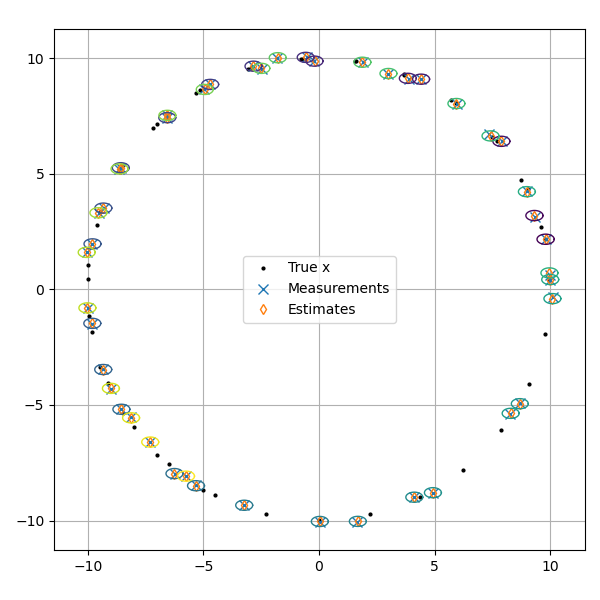

In [ ]:

colors = plt.cm.viridis(np.linspace(0, 1, n_measurements))

fig, ax = plt.subplots(1,1, figsize=[6,6], squeeze=True)
ax.plot(postrue_x, postrue_y, lw=0, marker='o', ms=2, color='k', label='True x')
ax.plot(posmeas_x, posmeas_y, lw=0, marker='x', ms=7, color='tab:blue', label='Measurements')
ax.plot(posest_x, posest_y, lw=0, marker='d', ms=5, color='tab:orange', mfc='none', label='Estimates')




### PLOTTING IN X-Y BUT WITH R-PHI MEAN. WRONG.
estimates_pos = np.vstack((posest_x, posest_y)).T
estimates_cov = kf.get_covariances(which='estimates')
estimates_pos_cov = [get_position_covariances(cov,state_order=1) for cov in estimates_cov]

for i, (xv, cov) in enumerate(zip(estimates_pos, estimates_pos_cov)):
    xy = utils.generate_covariance_ellipse(xv, cov, enclosed_frac=0.5)
    ax.plot(xy[0], xy[1], lw=1, color=colors[i])
    # ax.plot(xv[0], xv[1], c=colors[i])
ax.legend()

axkwargs = {
    # 'xticks': timevec[::10],
    # 'ylim': [-20, 20],
    # 'xlabel': 'Time [s]',
    # 'ylabel': 'Position difference from truth [m]',
    'aspect': 'equal',
}
ax.set(**axkwargs)
# from matplotlib.ticker import FuncFormatter

# ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: x / 100))
# ax.set_xlabel('x (100 m)')

ax.grid(True)
plt.tight_layout()
plt.show()

In [198]:
np.vstack((posest_x, posest_y)).T

array([[  1.92208245,   9.32657323],
       [  4.27969214,   8.95743826],
       [  1.60465176,  10.40540681],
       [  1.94239167,   9.26596647],
       [ -6.02312196,  -5.72331171],
       [ -5.32382527,  -7.82636113],
       [ 11.4909238 ,  -2.84038789],
       [  9.93208191,  -3.89047188],
       [ 10.76403449,  -2.20344493],
       [  9.24400742,   1.664495  ],
       [  8.20467994,   6.4067288 ],
       [  5.85436237,   9.1349898 ],
       [ -6.52660803,   8.2856979 ],
       [ -5.28035637,   9.85321684],
       [ -7.34544378,  -7.46375095],
       [ -4.00214301,  -9.66588071],
       [  0.92189421, -11.41990685],
       [  2.65024553,  -9.62315058],
       [  5.89420763,  -7.92039604],
       [  0.54843365, -10.37273048],
       [  9.38321184,  -2.85250996],
       [  7.02286484,   4.48965923],
       [  7.40076713,   4.23248568],
       [ -6.2866513 ,   7.01391074],
       [ -7.09165679,  -4.561594  ],
       [ -3.86617075,  -9.23609668],
       [ -9.30668761,   0.25324339],
 

In [245]:
plt.close('all')

# misc

In [13]:
a = np.ones(3)
print(a)
print(np.diag(a, k=1))

[1. 1. 1.]
[[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 0.]]


In [19]:
b = np.zeros([3,3])
idx = np.arange(2)
b[idx,idx+1] = 1
print(b)

[[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 0.]]


In [20]:
c = np.diag(np.ones(3), k=1)

In [21]:
c

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 0.]])

In [25]:
c @ c @ c @ c

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [14]:
se.gen_newtonian_motion_update_matrix(0.5, state_vec_order=4, approx_order=11)

---
1
[[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]]
1
---
2
[[0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
2
---
3
[[0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
6
---
4
[[0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
24


array([[0.        , 0.5       , 0.125     , 0.02083333, 0.00260417],
       [0.        , 0.        , 0.5       , 0.125     , 0.02083333],
       [0.        , 0.        , 0.        , 0.5       , 0.125     ],
       [0.        , 0.        , 0.        , 0.        , 0.5       ],
       [0.        , 0.        , 0.        , 0.        , 0.        ]])